# Track A — 등급표 재구성 + 엄격/비엄격 씬파일러 비교 (track_a_03)

담당: 김태헌 | 선행 노트북: track_a_01

## 목적

Track B의 track_b_10(ChiMerge 등급표 + H5)에 대응한다. `track_a_apply_v2_scored_R.csv`의
`SCORE_A2`는 인구변수 **포함**(F0, AUROC 0.820) 모델로 생성된 값이므로, 등급 경계도 F0
OOF 점수 기준으로 잡아야 같은 점수 스케일 위에서 비교가 성립한다(F2로 잡으면 스케일이
달라 등급 경계가 어긋난다).

핵심 질문: **엄격 씬파일러(순수 무이력)가 비엄격(폐계좌 보유자)보다 실제로 저위험 등급에
분포하는가?** — STEP 27R에서 이미 확인된 "엄격 < 비엄격(중앙값 0.010 vs 0.015)" 결과를
등급 단위로 재현한다.

## ⚠️ 데이터 한계

apply 파일에는 `AGE_BAND`가 없어 STEP 29의 연령 표준화 재현은 이 노트북에서 다루지 않는다.
(연령 정보 있는 apply 원본 피처 파일 `ckpt/apply_v2_input.parquet`를 구하면 추가 가능)

## 0. 환경 설정

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

RANDOM_STATE = 42
handoff_path = r'C:\Users\tehun\Desktop\multicamp\project\creditscore\personalCB'

LGB_PARAMS = dict(
    max_depth=2, num_leaves=4, min_child_samples=20,
    n_estimators=200, learning_rate=0.05,
    objective='binary', verbose=-1,
)
DOWNSAMPLE_RATIO = 50
N_ENSEMBLE = 5
N_GRADES = 9

FEATURES_A2 = [
    'AL012G005_prev', 'AL012G011_prev', 'AL012G019_prev',
    'DELTA_AL012G005_prev', 'DELTA_AL012G011_prev', 'DELTA_AL012G019_prev',
    'U81301010_prev', 'U81305010_prev', 'U81306010_prev',
    'AS120G001_prev',
]
POP_COLS = ['GENDER', 'AGE_BAND']


## 1. F0(인구 포함) OOF 점수 재생성

SCORE_A2와 같은 스케일(인구 포함 모델)로 등급 경계를 잡기 위해 F0 버전을 다시 OOF로 계산한다.

In [2]:
df_a2 = pd.read_csv(f'{handoff_path}/track_a_train_A2_v2.csv')
delta_cols = [c for c in df_a2.columns if c.startswith('DELTA_')]
df_a2[delta_cols] = df_a2[delta_cols].fillna(0)

X_f0 = df_a2[FEATURES_A2 + POP_COLS]
y24 = df_a2['TARGET_24M']
groups = df_a2['ID']

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_f0 = np.zeros(len(y24))

for fold, (tr_idx, va_idx) in enumerate(sgkf.split(X_f0, y24, groups)):
    X_tr, y_tr = X_f0.iloc[tr_idx], y24.iloc[tr_idx]
    X_va = X_f0.iloc[va_idx]
    pos_idx = y_tr[y_tr == 1].index
    neg_idx_all = y_tr[y_tr == 0].index
    n_neg_sample = min(len(neg_idx_all), len(pos_idx) * DOWNSAMPLE_RATIO)

    fold_pred = np.zeros(len(va_idx))
    for e in range(N_ENSEMBLE):
        rng = np.random.RandomState(RANDOM_STATE + fold * 1000 + e)
        neg_sample = rng.choice(neg_idx_all, size=n_neg_sample, replace=False)
        train_idx = np.concatenate([pos_idx.values, neg_sample])
        Xe, ye = X_tr.loc[train_idx], y_tr.loc[train_idx]
        model = lgb.LGBMClassifier(**LGB_PARAMS, random_state=RANDOM_STATE + e)
        model.fit(Xe, ye)
        fold_pred += model.predict_proba(X_va)[:, 1] / N_ENSEMBLE
    oof_f0[va_idx] = fold_pred
    print(f"fold {fold+1} 완료")

print(f"\nF0 OOF AUROC: {roc_auc_score(y24, oof_f0):.4f} (문서 참고치 0.820)")


fold 1 완료
fold 2 완료
fold 3 완료
fold 4 완료
fold 5 완료

F0 OOF AUROC: 0.8190 (문서 참고치 0.820)


## 2. ChiMerge 등급 경계 산출 (신용이력보유군 = 신규 신용진입자 기준)

Track B track_b_10과 동일한 방식. TARGET 정보를 이용해 통계적으로 의미 있는 9등급 경계를
만든다(균등분위가 아님).

In [3]:
def chimerge_fit(score, target, max_bins=9, initial_bins=100):
    score = np.asarray(score); target = np.asarray(target)
    init_edges = np.unique(np.quantile(score, np.linspace(0, 1, initial_bins + 1)))
    init_edges[0], init_edges[-1] = -np.inf, np.inf
    bin_id = np.digitize(score, init_edges[1:-1])
    n_bins = len(init_edges) - 1

    counts = np.zeros((n_bins, 2))
    for b in range(n_bins):
        mask = bin_id == b
        counts[b, 0] = (target[mask] == 0).sum()
        counts[b, 1] = (target[mask] == 1).sum()
    edges = list(init_edges)

    def chi2_adjacent(c1, c2):
        table = np.array([c1, c2])
        row_sums, col_sums = table.sum(axis=1), table.sum(axis=0)
        total = table.sum()
        if total == 0:
            return 0.0
        expected = np.outer(row_sums, col_sums) / total
        with np.errstate(divide='ignore', invalid='ignore'):
            terms = np.where(expected > 0, (table - expected) ** 2 / expected, 0)
        return terms.sum()

    while len(counts) > max_bins:
        chi2_values = [chi2_adjacent(counts[i], counts[i+1]) for i in range(len(counts)-1)]
        merge_idx = int(np.argmin(chi2_values))
        counts[merge_idx] = counts[merge_idx] + counts[merge_idx+1]
        counts = np.delete(counts, merge_idx+1, axis=0)
        del edges[merge_idx+1]
    return np.array(edges)

def assign_grade(scores, edges):
    return np.digitize(scores, edges[1:-1]) + 1

grade_edges = chimerge_fit(oof_f0, y24.values, max_bins=N_GRADES, initial_bins=100)
grade_entrants = assign_grade(oof_f0, grade_edges)

print("등급 경계:", grade_edges)
print("\n신규 신용진입자 등급별 인구비율(%):")
print((pd.Series(grade_entrants).value_counts(normalize=True).sort_index() * 100).round(1))


등급 경계: [      -inf 0.00199038 0.00339848 0.01114459 0.01149429 0.0148933
 0.01778509 0.02307971 0.05489046        inf]

신규 신용진입자 등급별 인구비율(%):
1     9.0
2    14.0
3    39.0
4     1.0
5     8.0
6     4.0
7     5.0
8    11.0
9     9.0
Name: proportion, dtype: float64


## 3. apply 집단(씬파일러 794,773명)에 같은 등급 경계 적용

`SCORE_A2`는 F0 모델로 생성된 값이라 오늘 계산한 등급 경계와 스케일이 일치한다.

In [4]:
df_apply = pd.read_csv(f'{handoff_path}/track_a_apply_v2_scored_R.csv')
grade_apply = assign_grade(df_apply['SCORE_A2'].values, grade_edges)
df_apply['grade'] = grade_apply

print("씬파일러 전체 등급별 인구비율(%):")
print((pd.Series(grade_apply).value_counts(normalize=True).sort_index() * 100).round(1))


씬파일러 전체 등급별 인구비율(%):
1     4.1
2     8.0
3    33.7
4     1.8
5    10.4
6     4.3
7     5.0
8    20.1
9    12.7
Name: proportion, dtype: float64


## 4. 핵심 검증 — 엄격 씬파일러 vs 비엄격 씬파일러

STEP 27R: 엄격 씬파일러(순수 무이력)가 비엄격(폐계좌 보유자)보다 낮은 위험 점수 분포를
보였다(중앙값 0.010 vs 0.015). 이번엔 등급 단위로 같은 비교를 한다.

In [5]:
strict_stats = df_apply.groupby('IS_STRICT').agg(
    인원수=('grade', 'size'),
    평균등급=('grade', 'mean'),
    중앙값등급=('grade', 'median'),
    평균점수=('SCORE_A2', 'mean'),
    중앙값점수=('SCORE_A2', 'median'),
).rename(index={True: '엄격(순수무이력)', False: '비엄격(폐계좌보유)'})

print("STEP 27R 원 결과 참고: 중앙값 점수 엄격 0.010 vs 비엄격 0.015 (엄격 < 비엄격)")
strict_stats


STEP 27R 원 결과 참고: 중앙값 점수 엄격 0.010 vs 비엄격 0.015 (엄격 < 비엄격)


,인원수,평균등급,중앙값등급,평균점수,중앙값점수
IS_STRICT,,,,,
비엄격(폐계좌보유),461202,5.611738,5.0,0.029795,0.014718
엄격(순수무이력),333571,4.523664,3.0,0.019361,0.009716


## 5. 등급 분포 시각화 + 저장

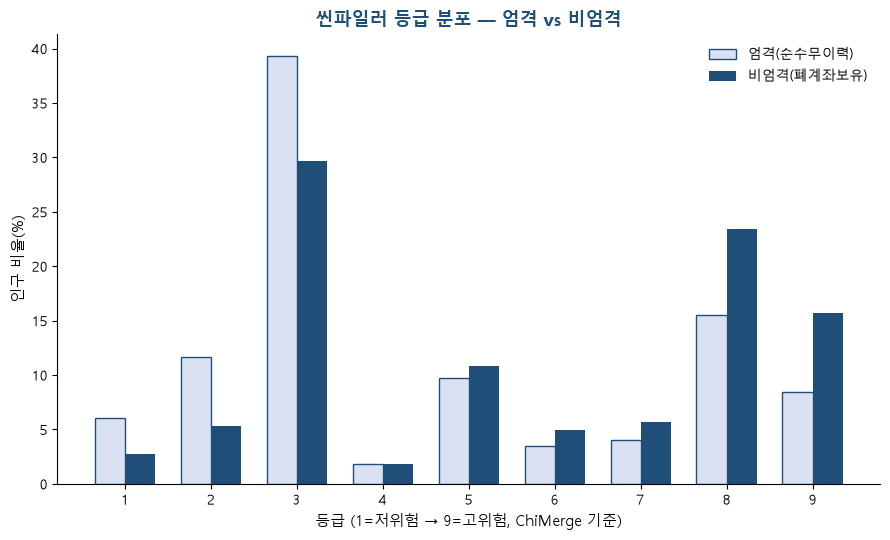

저장 완료: track_a_apply_grades.csv, track_a_strict_comparison.csv, 발표자료/trackA_03_엄격비엄격_등급분포.png


In [6]:
import matplotlib.pyplot as plt
import os

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
NAVY, ACCENT, NAVY_LIGHT = '#1F4E79', '#C00000', '#D9E1F2'

strict_dist = (df_apply[df_apply['IS_STRICT']]['grade'].value_counts(normalize=True).sort_index()*100).reindex(range(1,10), fill_value=0)
nonstrict_dist = (df_apply[~df_apply['IS_STRICT']]['grade'].value_counts(normalize=True).sort_index()*100).reindex(range(1,10), fill_value=0)

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(1, 10)
width = 0.35
ax.bar(x - width/2, strict_dist.values, width, label='엄격(순수무이력)', color=NAVY_LIGHT, edgecolor=NAVY)
ax.bar(x + width/2, nonstrict_dist.values, width, label='비엄격(폐계좌보유)', color=NAVY)
ax.set_xticks(x)
ax.set_xlabel('등급 (1=저위험 → 9=고위험, ChiMerge 기준)', fontsize=11)
ax.set_ylabel('인구 비율(%)', fontsize=11)
ax.set_title('씬파일러 등급 분포 — 엄격 vs 비엄격', fontsize=13, fontweight='bold', color=NAVY)
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()

output_dir = os.path.join(handoff_path, '발표자료')
os.makedirs(output_dir, exist_ok=True)
fig.savefig(os.path.join(output_dir, 'trackA_03_엄격비엄격_등급분포.png'), dpi=300, bbox_inches='tight')
plt.show()

df_apply[['ID','IS_STRICT','SCORE_A2','grade']].to_csv(f'{handoff_path}/track_a_apply_grades.csv', index=False, encoding='utf-8-sig')
strict_stats.to_csv(f'{handoff_path}/track_a_strict_comparison.csv', encoding='utf-8-sig')
print("저장 완료: track_a_apply_grades.csv, track_a_strict_comparison.csv, 발표자료/trackA_03_엄격비엄격_등급분포.png")
